# Ultrasound Model Comparison: Trained Models vs Baselines

This notebook compares:

- **Three trained EchoCare-CLIP models** saved from `experiment_training_Mar26.ipynb`
- **OpenAI CLIP** zero-shot baseline
- **BiomedCLIP** zero-shot baseline

using two evaluations on a **held-out test split** of the labeled ultrasound datasets:

1. **Alignment score**: mean cosine similarity of matched image-caption pairs  
2. **Classification accuracy**: classify each image into a label using **prompted label text** and image-text similarity

This notebook is intentionally focused on **BUSI** and **BrEaST** because those datasets have label columns in the CSVs, making classification evaluation meaningful.


In [1]:
# Install dependencies (run once)
!pip install -q monai transformers open_clip_torch einops pandas pillow matplotlib scikit-learn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 35.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.8 MB/s eta 0:00:00


In [2]:
import os
import hashlib
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from transformers import (
    CLIPModel,
    CLIPProcessor,
    CLIPTextModel,
    CLIPTokenizer,
)
from monai.networks.nets.swin_unetr import SwinTransformer

from open_clip import create_model_from_pretrained, get_tokenizer

def set_seed(seed=42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

2026-03-27 03:47:34.107906: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774583254.317132      54 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774583254.379098      54 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774583254.885172      54 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774583254.885198      54 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774583254.885201      54 computation_placer.cc:177] computation placer alr

Using device: cuda


In [3]:

config = {
    # ------------------------------------------------------------------
    # Data loading / splitting: match experiment_Mar21.ipynb
    # ------------------------------------------------------------------
    "prepared_data_root": "/kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed",

    # ------------------------------------------------------------------
    # Saved models
    # ------------------------------------------------------------------
    "saved_model_dir": "/kaggle/input/models/yiyangzhangyoung/ultraclip/transformers/default/1/saved_models_Mar25",
    "trained_models": {
        "MLP heads only": "echocare_clip_mlp_heads_only.pt",
        "MLP + image encoder": "echocare_clip_mlp_and_image_encoder.pt",
        "MLP + text encoder": "echocare_clip_mlp_and_text_encoder.pt",
    },

    # ------------------------------------------------------------------
    # Model settings (must match experiment_training_Mar26.ipynb)
    # ------------------------------------------------------------------
    "feature_size": 128,
    "in_channels": 3,
    "image_size": 256,
    "projection_dim": 256,
    "clip_model_name": "openai/clip-vit-base-patch32",
    "max_seq_len": 77,
    "img_mean": [0.485, 0.456, 0.406],
    "img_std": [0.229, 0.224, 0.225],

    # ------------------------------------------------------------------
    # Baseline model names
    # ------------------------------------------------------------------
    "openai_clip_model_name": "openai/clip-vit-base-patch32",
    "biomedclip_model_name": "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224",

    # ------------------------------------------------------------------
    # Evaluation split: EXACTLY like experiment_Mar21.ipynb
    # ------------------------------------------------------------------
    "test_size": 0.15,
    "val_size": 0.15,
    "random_seed": 42,
    "batch_size": 32,
    "num_workers": 0,
}
config


{'prepared_data_root': '/kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed',
 'saved_model_dir': '/kaggle/input/models/yiyangzhangyoung/ultraclip/transformers/default/1/saved_models_Mar25',
 'trained_models': {'MLP heads only': 'echocare_clip_mlp_heads_only.pt',
  'MLP + image encoder': 'echocare_clip_mlp_and_image_encoder.pt',
  'MLP + text encoder': 'echocare_clip_mlp_and_text_encoder.pt'},
 'feature_size': 128,
 'in_channels': 3,
 'image_size': 256,
 'projection_dim': 256,
 'clip_model_name': 'openai/clip-vit-base-patch32',
 'max_seq_len': 77,
 'img_mean': [0.485, 0.456, 0.406],
 'img_std': [0.229, 0.224, 0.225],
 'openai_clip_model_name': 'openai/clip-vit-base-patch32',
 'biomedclip_model_name': 'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224',
 'test_size': 0.15,
 'val_size': 0.15,
 'random_seed': 42,
 'batch_size': 32,
 'num_workers': 0}

## Load all prepared datasets and reproduce the same split logic as `experiment_Mar21.ipynb`

This section discovers every prepared dataset under `prepared_data_root`, auto-detects image-path and caption columns, resolves image paths, and then recreates the **same train/val/test split logic** used in `experiment_Mar21.ipynb`:

- `test_size = 0.15`
- `val_size = 0.15`
- `random_seed = 42`
- split stratified by **dataset source only**


In [4]:

def discover_datasets(root):
    """
    Walk the prepared_data root and return all (dataset_name, csv_path) pairs.
    A dataset folder is any directory that directly contains at least one .csv.
    If a folder has multiple CSVs, the largest one is used.
    """
    datasets = []
    for dirpath, dirnames, filenames in os.walk(root):
        csv_files = [f for f in filenames if f.lower().endswith(".csv")]
        if csv_files:
            dataset_name = os.path.basename(dirpath)
            csv_full = [os.path.join(dirpath, f) for f in csv_files]
            csv_full.sort(key=os.path.getsize, reverse=True)
            datasets.append((dataset_name, csv_full[0]))
    return sorted(datasets)


PATH_COL_CANDIDATES = [
    "file_name", "image_name", "path", "filename", "image_path", "filepath",
    "file", "image", "img_path", "img", "image_file"
]
CAPTION_COL_CANDIDATES = [
    "caption", "text_caption", "text_captions", "description", "text", "report",
    "finding", "findings", "annotation", "sentence"
]
LABEL_COL_CANDIDATES = ["label", "class", "condition", "diagnosis", "classification"]


def detect_column(df_columns, candidates):
    cols_lower = {c.lower(): c for c in df_columns}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    return None


def load_dataset_csv(csv_path, dataset_name):
    """
    Load a dataset CSV, auto-detecting path/caption columns.
    Returns unified columns: image_path, caption, dataset, label.
    Label is optional and may be NaN.
    """
    df = pd.read_csv(csv_path)

    path_col = detect_column(df.columns, PATH_COL_CANDIDATES)
    cap_col = detect_column(df.columns, CAPTION_COL_CANDIDATES)
    label_col = detect_column(df.columns, LABEL_COL_CANDIDATES)

    if path_col is None:
        raise ValueError(
            f"[{dataset_name}] Cannot detect image path column.\n"
            f"  Available: {list(df.columns)}\n"
            f"  Expected one of: {PATH_COL_CANDIDATES}"
        )
    if cap_col is None:
        raise ValueError(
            f"[{dataset_name}] Cannot detect caption column.\n"
            f"  Available: {list(df.columns)}\n"
            f"  Expected one of: {CAPTION_COL_CANDIDATES}"
        )

    out = pd.DataFrame({
        "image_path": df[path_col].astype(str),
        "caption": df[cap_col].astype(str),
        "dataset": dataset_name,
    })

    if label_col is not None:
        out["label"] = df[label_col].astype(str).str.strip().str.lower()
    else:
        out["label"] = pd.NA

    print(
        f"  [{dataset_name}] {len(out)} rows | "
        f"path_col={path_col!r} | caption_col={cap_col!r} | label_col={label_col!r}"
    )
    return out


def resolve_image_path(raw_path, csv_dir):
    """
    Try multiple strategies to locate an image file.
    Returns the first existing resolved path, or None.
    """
    basename = os.path.basename(str(raw_path))
    candidates = [
        str(raw_path),
        os.path.join(csv_dir, str(raw_path)),
        os.path.join(csv_dir, basename),
    ]
    # also try immediate subfolders of csv_dir
    try:
        for sub in os.listdir(csv_dir):
            subdir = os.path.join(csv_dir, sub)
            if os.path.isdir(subdir):
                candidates.append(os.path.join(subdir, basename))
    except Exception:
        pass

    seen = set()
    for p in candidates:
        if p in seen:
            continue
        seen.add(p)
        if os.path.exists(p):
            return os.path.abspath(p)
    return None


datasets_found = discover_datasets(config["prepared_data_root"])
print(f"Found {len(datasets_found)} dataset(s) under: {config['prepared_data_root']}\n")
for name, csv_path in datasets_found:
    print(f"  {name:40s}  ->  {csv_path}")

all_dfs = []
load_report = []

for dataset_name, csv_path in datasets_found:
    csv_dir = os.path.dirname(csv_path)
    try:
        df = load_dataset_csv(csv_path, dataset_name)
    except Exception as e:
        print(f"  [CSV ERROR] {dataset_name}: {e}")
        load_report.append((dataset_name, 0, 0, "CSV_ERROR"))
        continue

    resolved, n_ok, n_fail = [], 0, 0
    for raw_path in df["image_path"]:
        p = resolve_image_path(raw_path, csv_dir)
        resolved.append(p)
        if p is not None:
            n_ok += 1
        else:
            n_fail += 1

    df["resolved_path"] = resolved
    df_ok = df[df["resolved_path"].notna()].copy()
    df_ok["image_path"] = df_ok["resolved_path"]
    df_ok = df_ok.drop(columns=["resolved_path"])

    if len(df_ok) > 0:
        all_dfs.append(df_ok)

    status = "OK" if n_fail == 0 else f"{n_fail} missing"
    load_report.append((dataset_name, n_ok, n_fail, status))

print("\n" + "=" * 90)
print(f"{'Dataset':<42} {'Loaded':>8} {'Failed':>8}  Status")
print("=" * 90)
for name, n_ok, n_fail, status in load_report:
    ok_str = f"{n_ok:,}" if n_ok else "-"
    fail_str = f"{n_fail:,}" if n_fail else "-"
    print(f"{name:<42} {ok_str:>8} {fail_str:>8}  {status}")
print("=" * 90)
print(f"{'TOTAL':<42} {sum(r[1] for r in load_report):>8,} {sum(r[2] for r in load_report):>8,}")

if not all_dfs:
    raise RuntimeError(
        "No data loaded successfully! "
        f"Check that prepared_data_root exists: {config['prepared_data_root']}"
    )

full_df = pd.concat(all_dfs, ignore_index=True)[["image_path", "caption", "dataset", "label"]]
print(f"\nCombined dataset: {len(full_df):,} samples from {full_df['dataset'].nunique()} source(s)")
print(full_df["dataset"].value_counts())


Found 5 dataset(s) under: /kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed

  AULI_resized_images                       ->  /kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/Liver_ultrasound/AULI_resized_images/captions.csv
  BrEaST-Lesions_USG-images_and_masks       ->  /kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/BrEaST-Lesions_USG-images_and_masks/captions.csv
  Dataset_BUSI_with_GT                      ->  /kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/Dataset_BUSI_with_GT/all_captions.csv
  dataset_thyroid_resized_png               ->  /kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/Thyroid/dataset_thyroid_resized_png/thyroid_template_captions_with_paths.csv
  final_data                                ->  /kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/Lung_ultrasound/final_data/lung_captions.csv
  [AULI_resized_images] 735 rows | path_col='file_name' | caption_col='caption' | label_col=None
  [BrEaST-Lesions

In [5]:

# Reproduce the SAME split logic as experiment_Mar21.ipynb:
#   1) split full_df -> train_val_df + test_df with stratify by dataset
#   2) split train_val_df -> train_df + val_df with stratify by dataset
val_frac = config["val_size"] / (1.0 - config["test_size"])

def safe_split(df, test_size, stratify_col, seed):
    try:
        return train_test_split(
            df,
            test_size=test_size,
            stratify=df[stratify_col],
            random_state=seed,
        )
    except ValueError as e:
        print(f"  [WARNING] Stratified split failed ({e}). Using random split.")
        return train_test_split(df, test_size=test_size, random_state=seed)

train_val_df, test_df = safe_split(full_df, config["test_size"], "dataset", config["random_seed"])
train_df, val_df = safe_split(train_val_df, val_frac, "dataset", config["random_seed"])

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Split sizes (total = {len(full_df):,})")
print(f"  Train : {len(train_df):>6,}  ({100*len(train_df)/len(full_df):.1f}%)")
print(f"  Val   : {len(val_df):>6,}  ({100*len(val_df)/len(full_df):.1f}%)")
print(f"  Test  : {len(test_df):>6,}  ({100*len(test_df)/len(full_df):.1f}%)")

print("\nTest set by dataset:")
print(test_df["dataset"].value_counts())

labeled_test_df = test_df[test_df["label"].notna() & (test_df["label"].astype(str).str.lower() != "nan")].reset_index(drop=True)
print(f"\nLabeled test rows available for classification: {len(labeled_test_df):,}")
if len(labeled_test_df):
    print(labeled_test_df["label"].value_counts())


Split sizes (total = 5,114)
  Train :  3,579  (70.0%)
  Val   :    767  (15.0%)
  Test  :    768  (15.0%)

Test set by dataset:
dataset
dataset_thyroid_resized_png            344
final_data                             160
Dataset_BUSI_with_GT                   117
AULI_resized_images                    110
BrEaST-Lesions_USG-images_and_masks     37
Name: count, dtype: int64

Labeled test rows available for classification: 154
label
benign       89
malignant    40
normal       25
Name: count, dtype: int64


## Dataset / DataLoader for evaluation

For alignment-score evaluation we use the full held-out `test_df` from the same split logic as `experiment_Mar21.ipynb`. For classification, we restrict to `labeled_test_df` so unlabeled datasets do not break the prompt-based label evaluation.

In [6]:

class LabeledUltrasoundDataset(Dataset):
    def __init__(self, dataframe, split="test", cfg=config):
        self.df = dataframe.reset_index(drop=True)
        sz = cfg["image_size"]
        mean = cfg["img_mean"]
        std = cfg["img_std"]

        # deterministic transforms for evaluation
        self.transform = transforms.Compose([
            transforms.Resize(sz),
            transforms.CenterCrop(sz),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std),
        ])

    def __len__(self):
        return len(self.df)

    def _safe_str(self, x, default=""):
        if pd.isna(x):
            return default
        return str(x)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = self._safe_str(row["image_path"])
        image = Image.open(image_path).convert("RGB")
        image = self.transform(image)

        caption = self._safe_str(row["caption"], default="")
        label = self._safe_str(row["label"], default="unknown") if "label" in row.index else "unknown"
        dataset = self._safe_str(row["dataset"], default="unknown")

        return image, caption, label, dataset, image_path

test_dataset = LabeledUltrasoundDataset(test_df, split="test")
test_loader = DataLoader(
    test_dataset,
    batch_size=config["batch_size"],
    shuffle=False,
    num_workers=config["num_workers"],
    pin_memory=(device.type == "cuda"),
)

labeled_test_loader = None
if len(labeled_test_df) > 0:
    labeled_test_dataset = LabeledUltrasoundDataset(labeled_test_df, split="test")
    labeled_test_loader = DataLoader(
        labeled_test_dataset,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=config["num_workers"],
        pin_memory=(device.type == "cuda"),
    )

sample = test_dataset[0]
print("Sample image shape:", tuple(sample[0].shape))
print("Sample caption    :", sample[1][:120])
print("Sample label      :", sample[2])
print("Sample dataset    :", sample[3])


Sample image shape: (3, 256, 256)
Sample caption    : Echographic findings of liver showing benign characteristics.
Sample label      : unknown
Sample dataset    : AULI_resized_images


## Trained model definitions (must match training notebook)

In [7]:
class EchoCareImageEncoder(nn.Module):
    def __init__(
        self,
        feature_size=128,
        in_channels=3,
        projection_dim=256,
        use_checkpoint=True,
        freeze_encoder=False,
    ):
        super().__init__()
        self.encoder = SwinTransformer(
            in_chans=in_channels,
            embed_dim=feature_size,
            window_size=[8, 8],
            patch_size=[2, 2],
            depths=[2, 2, 18, 2],
            num_heads=[4, 8, 16, 32],
            mlp_ratio=4.0,
            qkv_bias=True,
            use_checkpoint=use_checkpoint,
            spatial_dims=2,
            use_v2=True,
        )

        encoder_out_dim = feature_size * (2 ** 4)  # 2048

        self.projection = nn.Sequential(
            nn.Linear(encoder_out_dim, encoder_out_dim),
            nn.ReLU(),
            nn.Linear(encoder_out_dim, projection_dim),
        )

        if freeze_encoder:
            for p in self.encoder.parameters():
                p.requires_grad = False

    def forward(self, x):
        feats = self.encoder(x)
        deep = feats[-1]
        emb = deep.mean(dim=(2, 3))
        emb = self.projection(emb)
        return F.normalize(emb, dim=-1)


class CLIPTextEncoder(nn.Module):
    def __init__(
        self,
        clip_model_name="openai/clip-vit-base-patch32",
        projection_dim=256,
        freeze_text_encoder=True,
    ):
        super().__init__()
        self.text_encoder = CLIPTextModel.from_pretrained(clip_model_name)
        text_out_dim = self.text_encoder.config.hidden_size

        if freeze_text_encoder:
            for p in self.text_encoder.parameters():
                p.requires_grad = False

        self.projection = nn.Sequential(
            nn.Linear(text_out_dim, text_out_dim),
            nn.ReLU(),
            nn.Linear(text_out_dim, projection_dim),
        )

    def forward(self, input_ids, attention_mask=None):
        outputs = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        text_emb = outputs.pooler_output
        text_emb = self.projection(text_emb)
        return F.normalize(text_emb, dim=-1)


class EchoCare_CLIP(nn.Module):
    def __init__(self, image_encoder, text_encoder, init_temperature=0.07):
        super().__init__()
        self.image_encoder = image_encoder
        self.text_encoder = text_encoder
        self.log_temperature = nn.Parameter(torch.log(torch.tensor(init_temperature)))

    def encode_image(self, images):
        return self.image_encoder(images)

    def encode_text(self, input_ids, attention_mask=None):
        return self.text_encoder(input_ids, attention_mask)

    def forward(self, images, input_ids, attention_mask=None):
        image_emb = self.encode_image(images)
        text_emb = self.encode_text(input_ids, attention_mask)
        temperature = self.log_temperature.exp()
        logits_per_image = (image_emb @ text_emb.T) / temperature
        logits_per_text = logits_per_image.T
        labels = torch.arange(image_emb.size(0), device=image_emb.device)
        loss_i2t = F.cross_entropy(logits_per_image, labels)
        loss_t2i = F.cross_entropy(logits_per_text, labels)
        loss = (loss_i2t + loss_t2i) / 2
        return loss, image_emb, text_emb


def build_trained_model():
    image_encoder = EchoCareImageEncoder(
        feature_size=config["feature_size"],
        in_channels=config["in_channels"],
        projection_dim=config["projection_dim"],
        freeze_encoder=False,
    )
    text_encoder = CLIPTextEncoder(
        clip_model_name=config["clip_model_name"],
        projection_dim=config["projection_dim"],
        freeze_text_encoder=False,
    )
    model = EchoCare_CLIP(image_encoder, text_encoder, init_temperature=0.07)
    return model

tokenizer = CLIPTokenizer.from_pretrained(config["clip_model_name"])

def tokenize_texts(texts, tokenizer, max_length=77, device="cpu"):
    encoded = tokenizer(
        texts,
        padding="max_length",
        max_length=max_length,
        truncation=True,
        return_tensors="pt",
    )
    return encoded["input_ids"].to(device), encoded["attention_mask"].to(device)

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

## Evaluation utilities

In [8]:
@torch.no_grad()
def compute_trained_model_alignment_score(model, dataloader, tokenizer, device):
    model.eval()
    all_img, all_txt = [], []

    for images, texts, labels, datasets, paths in tqdm(dataloader, desc="Trained model alignment", leave=False):
        images = images.to(device)
        ids, mask = tokenize_texts(list(texts), tokenizer, max_length=config["max_seq_len"], device=device)
        img_emb = model.encode_image(images)
        txt_emb = model.encode_text(ids, mask)
        all_img.append(img_emb.cpu())
        all_txt.append(txt_emb.cpu())

    img_embs = torch.cat(all_img, dim=0)
    txt_embs = torch.cat(all_txt, dim=0)

    paired_sim = (img_embs * txt_embs).sum(dim=1).mean().item()
    all_sim = img_embs @ txt_embs.T
    off_mask = ~torch.eye(img_embs.size(0), dtype=torch.bool)
    cross_sim = all_sim[off_mask].mean().item()
    return paired_sim, cross_sim


@torch.no_grad()
def compute_openai_clip_alignment_score_from_df(df, model, processor, device, batch_size=32):
    all_img, all_txt = [], []
    for start in tqdm(range(0, len(df), batch_size), desc="OpenAI CLIP baseline", leave=False):
        batch_df = df.iloc[start:start + batch_size]
        pil_images = [Image.open(p).convert("RGB") for p in batch_df["image_path"].tolist()]
        texts = batch_df["caption"].tolist()

        inputs = processor(
            text=texts,
            images=pil_images,
            return_tensors="pt",
            padding=True,
            truncation=True,
        ).to(device)

        outputs = model(**inputs)
        image_features = F.normalize(outputs.image_embeds, dim=-1)
        text_features = F.normalize(outputs.text_embeds, dim=-1)

        all_img.append(image_features.cpu())
        all_txt.append(text_features.cpu())

    img_embs = torch.cat(all_img, dim=0)
    txt_embs = torch.cat(all_txt, dim=0)

    paired_sim = (img_embs * txt_embs).sum(dim=1).mean().item()
    all_sim = img_embs @ txt_embs.T
    off_mask = ~torch.eye(img_embs.size(0), dtype=torch.bool)
    cross_sim = all_sim[off_mask].mean().item()
    return paired_sim, cross_sim


@torch.no_grad()
def compute_biomedclip_alignment_score_from_df(df, model, preprocess, tokenizer, device, batch_size=32):
    all_img, all_txt = [], []
    for start in tqdm(range(0, len(df), batch_size), desc="BiomedCLIP baseline", leave=False):
        batch_df = df.iloc[start:start + batch_size]
        pil_images = [Image.open(p).convert("RGB") for p in batch_df["image_path"].tolist()]
        images = torch.stack([preprocess(img) for img in pil_images]).to(device)
        texts = batch_df["caption"].tolist()
        text_tokens = tokenizer(texts, context_length=256).to(device)

        image_features = F.normalize(model.encode_image(images), dim=-1)
        text_features = F.normalize(model.encode_text(text_tokens), dim=-1)

        all_img.append(image_features.cpu())
        all_txt.append(text_features.cpu())

    img_embs = torch.cat(all_img, dim=0)
    txt_embs = torch.cat(all_txt, dim=0)

    paired_sim = (img_embs * txt_embs).sum(dim=1).mean().item()
    all_sim = img_embs @ txt_embs.T
    off_mask = ~torch.eye(img_embs.size(0), dtype=torch.bool)
    cross_sim = all_sim[off_mask].mean().item()
    return paired_sim, cross_sim


# Prompted-label classification is more reasonable than raw label strings.
# These models were trained on natural-language captions, not just class names.
def build_label_prompt(label):
    label = str(label).strip().lower()
    return f"An ultrasound image of breast with {label} findings."


@torch.no_grad()
def classify_with_trained_model(model, dataloader, label_prompts, tokenizer, device):
    model.eval()
    label_names = list(label_prompts.keys())
    prompt_texts = [label_prompts[l] for l in label_names]
    ids, mask = tokenize_texts(prompt_texts, tokenizer, max_length=config["max_seq_len"], device=device)
    text_embs = model.encode_text(ids, mask)  # (L, D)

    y_true, y_pred = [], []
    for images, texts, labels, datasets, paths in tqdm(dataloader, desc="Trained model classification", leave=False):
        images = images.to(device)
        img_embs = model.encode_image(images)  # (B, D)
        sims = img_embs @ text_embs.T          # (B, L)
        pred_idx = sims.argmax(dim=1).cpu().numpy()

        y_true.extend(list(labels))
        y_pred.extend([label_names[i] for i in pred_idx])

    acc = accuracy_score(y_true, y_pred)
    return acc, y_true, y_pred


@torch.no_grad()
def classify_with_openai_clip(df, label_prompts, model, processor, device, batch_size=32):
    model.eval()

    label_names = list(label_prompts.keys())
    label_texts = [label_prompts[k] for k in label_names]

    text_inputs = processor(
        text=label_texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
    ).to(device)

    text_out = model.get_text_features(
        input_ids=text_inputs["input_ids"],
        attention_mask=text_inputs["attention_mask"],
    )

    # Some transformers versions return a structured output instead of a tensor
    if hasattr(text_out, "pooler_output") and text_out.pooler_output is not None:
        text_out = text_out.pooler_output
    elif hasattr(text_out, "last_hidden_state"):
        text_out = text_out.last_hidden_state[:, 0, :]

    text_embs = F.normalize(text_out, dim=-1)

    y_true, y_pred = [], []

    for start in tqdm(range(0, len(df), batch_size), desc="OpenAI CLIP classification", leave=False):
        batch_df = df.iloc[start:start + batch_size]

        pil_images = [Image.open(p).convert("RGB") for p in batch_df["image_path"].tolist()]
        true_labels = batch_df["label"].tolist()

        img_inputs = processor(
            images=pil_images,
            return_tensors="pt",
        ).to(device)

        img_out = model.get_image_features(pixel_values=img_inputs["pixel_values"])

        if hasattr(img_out, "pooler_output") and img_out.pooler_output is not None:
            img_out = img_out.pooler_output
        elif hasattr(img_out, "last_hidden_state"):
            img_out = img_out.last_hidden_state[:, 0, :]

        img_embs = F.normalize(img_out, dim=-1)

        sims = img_embs @ text_embs.T
        pred_idx = sims.argmax(dim=1).cpu().tolist()
        pred_labels = [label_names[i] for i in pred_idx]

        y_true.extend(true_labels)
        y_pred.extend(pred_labels)

    acc = accuracy_score(y_true, y_pred)
    return acc, y_true, y_pred

@torch.no_grad()
def classify_with_biomedclip(df, label_prompts, model, preprocess, tokenizer, device, batch_size=32):
    label_names = list(label_prompts.keys())
    prompt_texts = [label_prompts[l] for l in label_names]
    text_tokens = tokenizer(prompt_texts, context_length=256).to(device)
    text_embs = F.normalize(model.encode_text(text_tokens), dim=-1)

    y_true, y_pred = [], []
    for start in tqdm(range(0, len(df), batch_size), desc="BiomedCLIP classification", leave=False):
        batch_df = df.iloc[start:start + batch_size]
        pil_images = [Image.open(p).convert("RGB") for p in batch_df["image_path"].tolist()]
        images = torch.stack([preprocess(img) for img in pil_images]).to(device)
        img_embs = F.normalize(model.encode_image(images), dim=-1)
        sims = img_embs @ text_embs.T
        pred_idx = sims.argmax(dim=1).cpu().numpy()

        y_true.extend(batch_df["label"].tolist())
        y_pred.extend([label_names[i] for i in pred_idx])

    acc = accuracy_score(y_true, y_pred)
    return acc, y_true, y_pred

## Load baseline models

In [9]:
print("Loading OpenAI CLIP baseline...")
openai_clip_model = CLIPModel.from_pretrained(config["openai_clip_model_name"]).to(device).eval()
openai_clip_processor = CLIPProcessor.from_pretrained(config["openai_clip_model_name"])

print("Loading BiomedCLIP baseline...")
biomedclip_model, biomedclip_preprocess = create_model_from_pretrained(config["biomedclip_model_name"])
biomedclip_tokenizer = get_tokenizer(config["biomedclip_model_name"])
biomedclip_model = biomedclip_model.to(device).eval()

print("Baselines loaded.")

Loading OpenAI CLIP baseline...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

open_clip_pytorch_model.bin:   0%|          | 0.00/784M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Baselines loaded.


## Load the three trained models

In [10]:
trained_models = {}

for model_name, filename in config["trained_models"].items():
    model_path = Path(config["saved_model_dir"]) / filename
    if not model_path.exists():
        raise FileNotFoundError(f"Missing trained model file: {model_path}")

    model = build_trained_model().to(device)
    state_dict = torch.load(model_path, map_location=device)
    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    model.eval()

    print(f"Loaded {model_name}")
    print(f"  file      : {model_path}")
    print(f"  missing   : {missing[:5]}")
    print(f"  unexpected: {unexpected[:5]}")

    trained_models[model_name] = model

print("\nLoaded trained models:", list(trained_models.keys()))

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.

Loaded MLP heads only
  file      : /kaggle/input/models/yiyangzhangyoung/ultraclip/transformers/default/1/saved_models_Mar25/echocare_clip_mlp_heads_only.pt
  missing   : []
  unexpected: []


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.

Loaded MLP + image encoder
  file      : /kaggle/input/models/yiyangzhangyoung/ultraclip/transformers/default/1/saved_models_Mar25/echocare_clip_mlp_and_image_encoder.pt
  missing   : []
  unexpected: []


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.

Loaded MLP + text encoder
  file      : /kaggle/input/models/yiyangzhangyoung/ultraclip/transformers/default/1/saved_models_Mar25/echocare_clip_mlp_and_text_encoder.pt
  missing   : []
  unexpected: []

Loaded trained models: ['MLP heads only', 'MLP + image encoder', 'MLP + text encoder']


## Alignment-score comparison on held-out test set

This uses the **same held-out test split logic as `experiment_Mar21.ipynb`** and evaluates all models on:

- **paired alignment score**: mean cosine similarity of matched image-caption pairs
- **cross-paired alignment score**: mean cosine similarity across mismatched image-caption pairs


In [11]:
alignment_rows = []

# Baseline: OpenAI CLIP
paired, cross = compute_openai_clip_alignment_score_from_df(
    test_df, openai_clip_model, openai_clip_processor, device, batch_size=config["batch_size"]
)
alignment_rows.append({"model": "OpenAI CLIP", "paired_similarity": paired, "cross_pair_similarity": cross})

# Baseline: BiomedCLIP
paired, cross = compute_biomedclip_alignment_score_from_df(
    test_df, biomedclip_model, biomedclip_preprocess, biomedclip_tokenizer, device, batch_size=config["batch_size"]
)
alignment_rows.append({"model": "BiomedCLIP", "paired_similarity": paired, "cross_pair_similarity": cross})

# Trained models
for model_name, model in trained_models.items():
    paired, cross = compute_trained_model_alignment_score(
        model, test_loader, tokenizer, device
    )
    alignment_rows.append({"model": model_name, "paired_similarity": paired, "cross_pair_similarity": cross})

alignment_results = pd.DataFrame(alignment_rows).sort_values("paired_similarity", ascending=False).reset_index(drop=True)
alignment_results

OpenAI CLIP baseline:   0%|          | 0/24 [00:00<?, ?it/s]

BiomedCLIP baseline:   0%|          | 0/24 [00:00<?, ?it/s]

Trained model alignment:   0%|          | 0/24 [00:00<?, ?it/s]

Trained model alignment:   0%|          | 0/24 [00:00<?, ?it/s]

Trained model alignment:   0%|          | 0/24 [00:00<?, ?it/s]

,model,paired_similarity,cross_pair_similarity
0,MLP + text encoder,0.492159,0.122588
1,MLP + image encoder,0.458704,0.090961
2,BiomedCLIP,0.432020,0.361108
3,MLP heads only,0.378668,0.059023
4,OpenAI CLIP,0.329419,0.327219


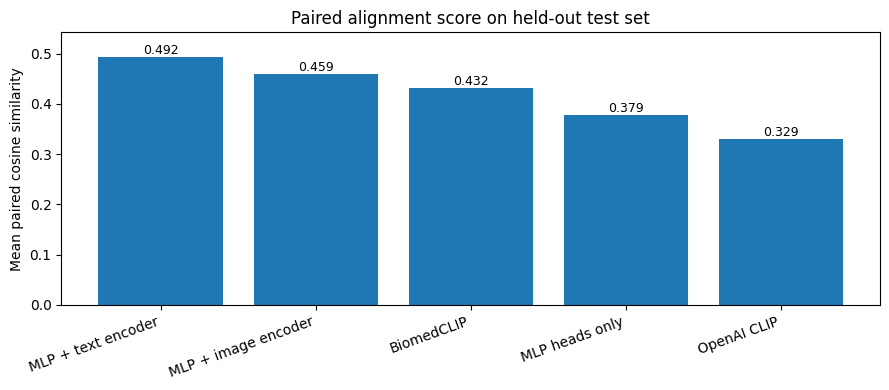

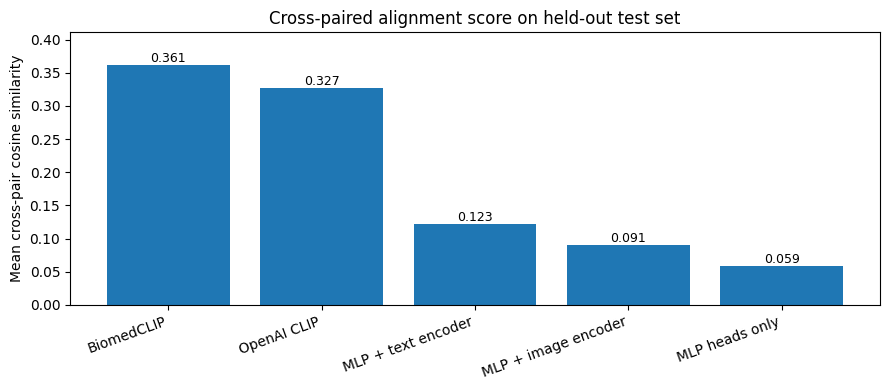

In [12]:

plot_df = alignment_results.copy()

# Plot 1: paired alignment score
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(plot_df["model"], plot_df["paired_similarity"])
ax.set_ylabel("Mean paired cosine similarity")
ax.set_title("Paired alignment score on held-out test set")
ax.set_ylim(min(0, plot_df["paired_similarity"].min() - 0.05),
            plot_df["paired_similarity"].max() + 0.05)
plt.xticks(rotation=20, ha="right")
for b in bars:
    ax.text(
        b.get_x() + b.get_width()/2,
        b.get_height(),
        f"{b.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
plt.tight_layout()
plt.show()

# Plot 2: cross-paired alignment score
cross_plot_df = alignment_results.sort_values("cross_pair_similarity", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(cross_plot_df["model"], cross_plot_df["cross_pair_similarity"])
ax.set_ylabel("Mean cross-pair cosine similarity")
ax.set_title("Cross-paired alignment score on held-out test set")
ax.set_ylim(min(0, cross_plot_df["cross_pair_similarity"].min() - 0.05),
            cross_plot_df["cross_pair_similarity"].max() + 0.05)
plt.xticks(rotation=20, ha="right")
for b in bars:
    ax.text(
        b.get_x() + b.get_width()/2,
        b.get_height(),
        f"{b.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
plt.tight_layout()
plt.show()


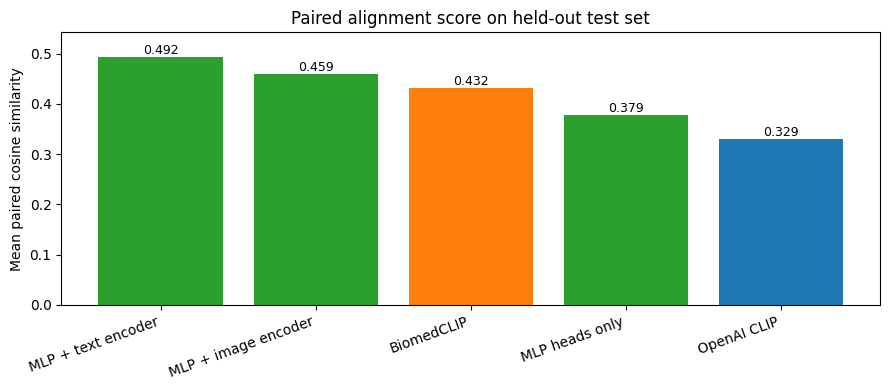

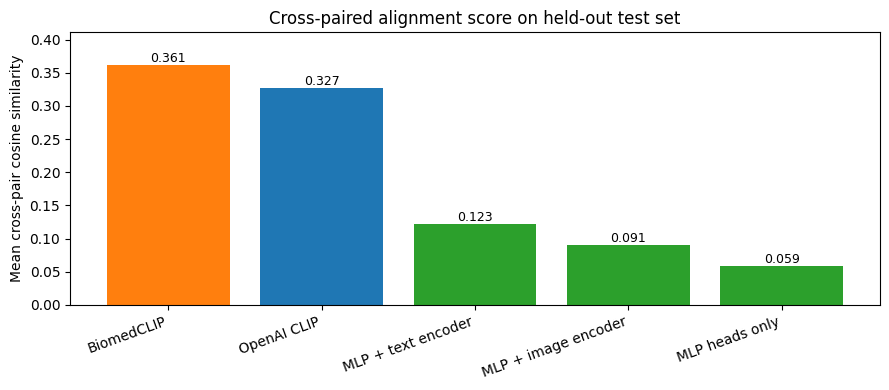

In [18]:
# Define colors per model (edit names if needed)
model_colors = {
    "OpenAI CLIP": "#1f77b4",
    "BiomedCLIP": "#ff7f0e",
    "MLP head only": "#2ca02c",
    "Image encoder finetuned": "#d62728",
    "Text encoder finetuned": "#9467bd",
}

# Default color for trained models
default_trained_color = "#2ca02c"  # green

def get_colors(models):
    return [
        model_colors[m] if m in model_colors else default_trained_color
        for m in models
    ]


# -----------------------
# Plot 1: paired alignment
# -----------------------
plot_df = alignment_results.copy()
colors = get_colors(plot_df["model"])

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(plot_df["model"], plot_df["paired_similarity"], color=colors)

ax.set_ylabel("Mean paired cosine similarity")
ax.set_title("Paired alignment score on held-out test set")

ax.set_ylim(
    min(0, plot_df["paired_similarity"].min() - 0.05),
    plot_df["paired_similarity"].max() + 0.05
)

plt.xticks(rotation=20, ha="right")

for b in bars:
    ax.text(
        b.get_x() + b.get_width()/2,
        b.get_height(),
        f"{b.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()


# -----------------------
# Plot 2: cross-paired alignment
# -----------------------
cross_plot_df = alignment_results.sort_values("cross_pair_similarity", ascending=False).reset_index(drop=True)
colors = get_colors(cross_plot_df["model"])

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(cross_plot_df["model"], cross_plot_df["cross_pair_similarity"], color=colors)

ax.set_ylabel("Mean cross-pair cosine similarity")
ax.set_title("Cross-paired alignment score on held-out test set")

ax.set_ylim(
    min(0, cross_plot_df["cross_pair_similarity"].min() - 0.05),
    cross_plot_df["cross_pair_similarity"].max() + 0.05
)

plt.xticks(rotation=20, ha="right")

for b in bars:
    ax.text(
        b.get_x() + b.get_width()/2,
        b.get_height(),
        f"{b.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

## Classification via image-to-label prompt alignment (labeled test subset only)

Classification is evaluated only on `labeled_test_df`, which is the subset of the held-out test split that contains valid labels. This keeps the split consistent with `experiment_Mar21.ipynb` while avoiding unlabeled datasets during label-prompt evaluation.

In [13]:

if len(labeled_test_df) == 0:
    raise ValueError("No labeled rows are available in the held-out test split, so classification cannot be evaluated.")

label_names = sorted(labeled_test_df["label"].dropna().astype(str).str.lower().unique().tolist())
label_prompts = {label: build_label_prompt(label) for label in label_names}

print("Label prompts used for classification:")
for label, prompt in label_prompts.items():
    print(f"  {label:12s} -> {prompt}")


Label prompts used for classification:
  benign       -> An ultrasound image of breast with benign findings.
  malignant    -> An ultrasound image of breast with malignant findings.
  normal       -> An ultrasound image of breast with normal findings.


In [14]:
classification_rows = []
classification_details = {}

# OpenAI CLIP
acc, y_true, y_pred = classify_with_openai_clip(
    labeled_test_df, label_prompts, openai_clip_model, openai_clip_processor, device, batch_size=config["batch_size"]
)
classification_rows.append({"model": "OpenAI CLIP", "accuracy": acc})
classification_details["OpenAI CLIP"] = (y_true, y_pred)

# BiomedCLIP
acc, y_true, y_pred = classify_with_biomedclip(
    labeled_test_df, label_prompts, biomedclip_model, biomedclip_preprocess, biomedclip_tokenizer, device, batch_size=config["batch_size"]
)
classification_rows.append({"model": "BiomedCLIP", "accuracy": acc})
classification_details["BiomedCLIP"] = (y_true, y_pred)

# Trained models
for model_name, model in trained_models.items():
    acc, y_true, y_pred = classify_with_trained_model(
        model, labeled_test_loader, label_prompts, tokenizer, device
    )
    classification_rows.append({"model": model_name, "accuracy": acc})
    classification_details[model_name] = (y_true, y_pred)

classification_results = pd.DataFrame(classification_rows).sort_values("accuracy", ascending=False).reset_index(drop=True)
classification_results

OpenAI CLIP classification:   0%|          | 0/5 [00:00<?, ?it/s]

BiomedCLIP classification:   0%|          | 0/5 [00:00<?, ?it/s]

Trained model classification:   0%|          | 0/5 [00:00<?, ?it/s]

Trained model classification:   0%|          | 0/5 [00:00<?, ?it/s]

Trained model classification:   0%|          | 0/5 [00:00<?, ?it/s]

,model,accuracy
0,MLP + text encoder,0.545455
1,MLP heads only,0.532468
2,MLP + image encoder,0.428571
3,OpenAI CLIP,0.409091
4,BiomedCLIP,0.350649


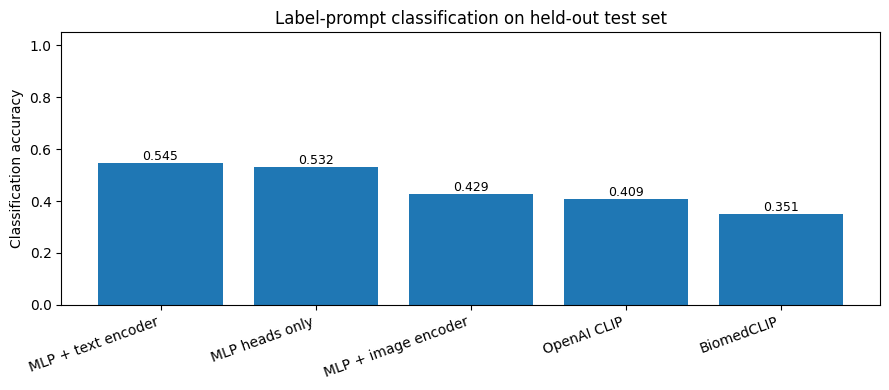

In [15]:
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(classification_results["model"], classification_results["accuracy"])
ax.set_ylabel("Classification accuracy")
ax.set_title("Label-prompt classification on held-out test set")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{b.get_height():.3f}",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

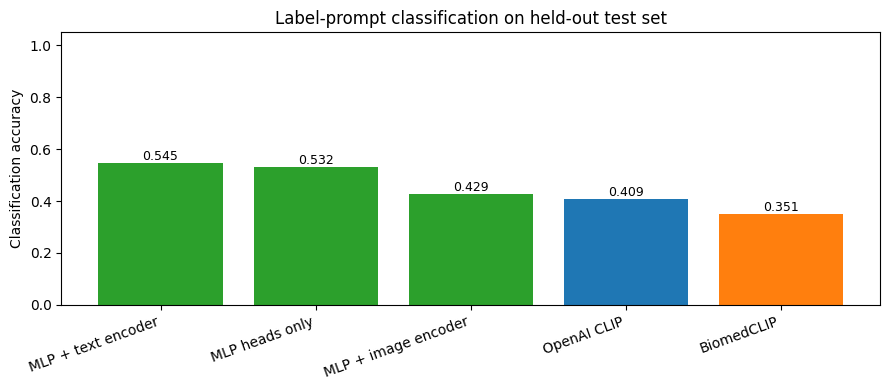

In [19]:
# Define colors (same mapping as alignment plots)
model_colors = {
    "OpenAI CLIP": "#1f77b4",
    "BiomedCLIP": "#ff7f0e",
    "MLP head only": "#2ca02c",
    "Image encoder finetuned": "#d62728",
    "Text encoder finetuned": "#9467bd",
}

default_trained_color = "#2ca02c"  # green

def get_colors(models):
    return [
        model_colors[m] if m in model_colors else default_trained_color
        for m in models
    ]

# Get colors
colors = get_colors(classification_results["model"])

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(classification_results["model"], classification_results["accuracy"], color=colors)

ax.set_ylabel("Classification accuracy")
ax.set_title("Label-prompt classification on held-out test set")
ax.set_ylim(0, 1.05)

plt.xticks(rotation=20, ha="right")

for b in bars:
    ax.text(
        b.get_x() + b.get_width()/2,
        b.get_height(),
        f"{b.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

## Optional: inspect per-model classification reports

In [16]:
for model_name in classification_results["model"].tolist():
    print("=" * 80)
    print(model_name)
    y_true, y_pred = classification_details[model_name]
    print(classification_report(y_true, y_pred, digits=4))

MLP + text encoder
              precision    recall  f1-score   support

      benign     0.7358    0.4382    0.5493        89
   malignant     0.4384    0.8000    0.5664        40
      normal     0.4643    0.5200    0.4906        25

    accuracy                         0.5455       154
   macro avg     0.5462    0.5861    0.5354       154
weighted avg     0.6145    0.5455    0.5442       154

MLP heads only
              precision    recall  f1-score   support

      benign     0.7308    0.4270    0.5390        89
   malignant     0.7273    0.6000    0.6575        40
      normal     0.2899    0.8000    0.4255        25

    accuracy                         0.5325       154
   macro avg     0.5826    0.6090    0.5407       154
weighted avg     0.6583    0.5325    0.5514       154

MLP + image encoder
              precision    recall  f1-score   support

      benign     0.8235    0.3146    0.4553        89
   malignant     0.5278    0.4750    0.5000        40
      normal     0.22

In [17]:
# Save summary tables
results_dir = Path(config["saved_model_dir"]).parent / "evaluation_results"
results_dir.mkdir(parents=True, exist_ok=True)

alignment_results.to_csv(results_dir / "alignment_results.csv", index=False)
classification_results.to_csv(results_dir / "classification_results.csv", index=False)

print("Saved:")
print(" ", results_dir / "alignment_results.csv")
print(" ", results_dir / "classification_results.csv")

OSError: [Errno 30] Read-only file system: '/kaggle/input/models/yiyangzhangyoung/ultraclip/transformers/default/1/evaluation_results'